<a href="https://colab.research.google.com/github/bry-cun/la-liga-match-prediction/blob/main/La_Liga_Match_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Research Question

Can match-level features such as recent team form, goal differences, and venue performance be used to predict match outcomes and simulate full La Liga seasons using probabilistic modeling?

# La Liga Match Outcome Prediction & Season Simulation

This project predicts La Liga match outcomes using machine learning and simulates full seasons to estimate team performance and title probabilities.

The goal is to move beyond predicting a single league winner by modeling match-level uncertainty and generating probabilistic season outcomes.

Key components:
- Exploratory Data Analysis (EDA)
- Feature Engineering (team form & venue performance)
- Classification Models (Logistic Regression, Random Forest)
- Monte Carlo Simulation for season forecasting

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
plt.rcParams['figure.figsize'] = (10, 6)

## Dataset Overview

The dataset contains historical La Liga match results from 1995 to 2025.

Key variables include:
- Match results (Home Win, Draw, Away Win)
- Goals scored and conceded
- Team and opponent information
- Match date and season

These variables allow us to construct team performance metrics over time.

This dataset is used to construct match-level features and train models to predict match outcomes, which are then used to simulate full league seasons.

In [ ]:
df = pd.read_csv('LaLiga_Matches.csv')
df.head()

,Season,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR
0,1995-96,02-09-1995,La Coruna,Valencia,3,0,H,2.0,0.0,H
1,1995-96,02-09-1995,Sp Gijon,Albacete,3,0,H,3.0,0.0,H
2,1995-96,03-09-1995,Ath Bilbao,Santander,4,0,H,2.0,0.0,H
3,1995-96,03-09-1995,Ath Madrid,Sociedad,4,1,H,1.0,1.0,D
4,1995-96,03-09-1995,Celta,Compostela,0,1,A,0.0,0.0,D


In [ ]:
print("Shape of dataset:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
df.info()

Shape of dataset: (11664, 10)

Columns:
['Season', 'Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'HTHG', 'HTAG', 'HTR']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11664 entries, 0 to 11663
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Season    11664 non-null  object 
 1   Date      11664 non-null  object 
 2   HomeTeam  11664 non-null  object 
 3   AwayTeam  11664 non-null  object 
 4   FTHG      11664 non-null  int64  
 5   FTAG      11664 non-null  int64  
 6   FTR       11664 non-null  object 
 7   HTHG      11662 non-null  float64
 8   HTAG      11662 non-null  float64
 9   HTR       11662 non-null  object 
dtypes: float64(2), int64(2), object(6)
memory usage: 911.4+ KB


In [ ]:
print("Missing values by column:")
print(df.isnull().sum())

print("\nMissing value percentages:")
print((df.isnull().sum() / len(df) * 100).round(4))

print("\nFull duplicates:", df.duplicated().sum())
print("Match duplicates:",
      df.duplicated(subset=['Season', 'Date', 'HomeTeam', 'AwayTeam']).sum())

Missing values by column:
Season      0
Date        0
HomeTeam    0
AwayTeam    0
FTHG        0
FTAG        0
FTR         0
HTHG        2
HTAG        2
HTR         2
dtype: int64

Missing value percentages:
Season      0.0000
Date        0.0000
HomeTeam    0.0000
AwayTeam    0.0000
FTHG        0.0000
FTAG        0.0000
FTR         0.0000
HTHG        0.0171
HTAG        0.0171
HTR         0.0171
dtype: float64

Full duplicates: 0
Match duplicates: 0


In [ ]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
print("Invalid parsed dates:", df['Date'].isnull().sum())
df[['Season', 'Date']].head()

Invalid parsed dates: 0


,Season,Date
0,1995-96,1995-09-02
1,1995-96,1995-09-02
2,1995-96,1995-09-03
3,1995-96,1995-09-03
4,1995-96,1995-09-03


## Exploratory Data Analysis

Home teams win more frequently than away teams, indicating a strong home advantage.

Goal distributions are right-skewed, with most matches having 0–3 goals.

Season trends show relatively stable scoring patterns across years.

In [ ]:
print("Full-time result counts:")
print(df['FTR'].value_counts())

print("\nFull-time result percentages:")
print((df['FTR'].value_counts(normalize=True) * 100).round(2))

Full-time result counts:
FTR
H    5500
A    3172
D    2992
Name: count, dtype: int64

Full-time result percentages:
FTR
H    47.15
A    27.19
D    25.65
Name: proportion, dtype: float64


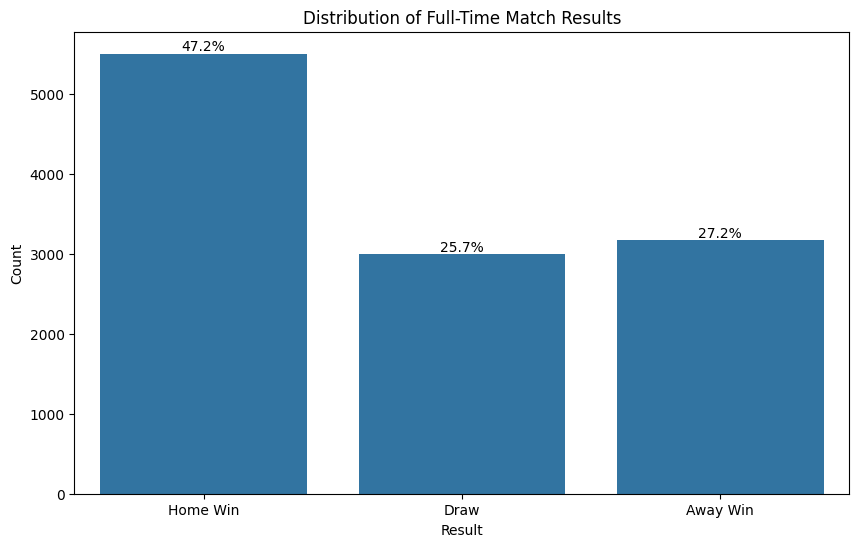

In [ ]:
result_map = {'H': 'Home Win', 'D': 'Draw', 'A': 'Away Win'}
df['FTR_Label'] = df['FTR'].map(result_map)

sns.countplot(x='FTR_Label', data=df, order=['Home Win', 'Draw', 'Away Win'])

total = len(df)
for p in plt.gca().patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    plt.gca().annotate(
        percentage,
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.title('Distribution of Full-Time Match Results')
plt.xlabel('Result')
plt.ylabel('Count')
plt.show()

In [ ]:
print("Average home goals:", round(df['FTHG'].mean(), 3))
print("Average away goals:", round(df['FTAG'].mean(), 3))

Average home goals: 1.547
Average away goals: 1.119


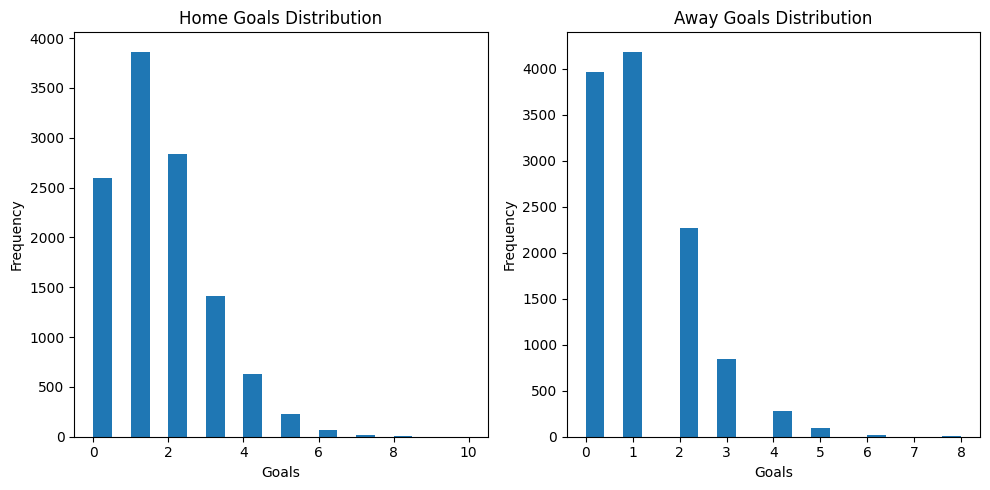

In [ ]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.hist(df['FTHG'], bins=20)
plt.title('Home Goals Distribution')
plt.xlabel('Goals')
plt.ylabel('Frequency')

plt.subplot(1,2,2)
plt.hist(df['FTAG'], bins=20)
plt.title('Away Goals Distribution')
plt.xlabel('Goals')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [ ]:
df['TotalGoals'] = df['FTHG'] + df['FTAG']
print(df['TotalGoals'].describe())

count    11664.000000
mean         2.665724
std          1.681531
min          0.000000
25%          1.000000
50%          2.000000
75%          4.000000
max         12.000000
Name: TotalGoals, dtype: float64


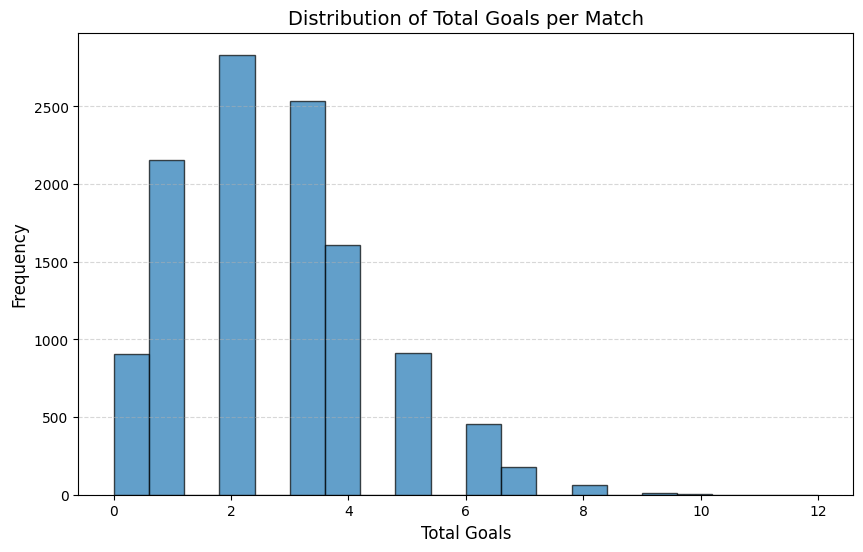

In [ ]:
plt.figure(figsize=(10,6))
plt.hist(df['TotalGoals'], bins=20, edgecolor='black', alpha=0.7)
plt.title('Distribution of Total Goals per Match', fontsize=14)
plt.xlabel('Total Goals', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

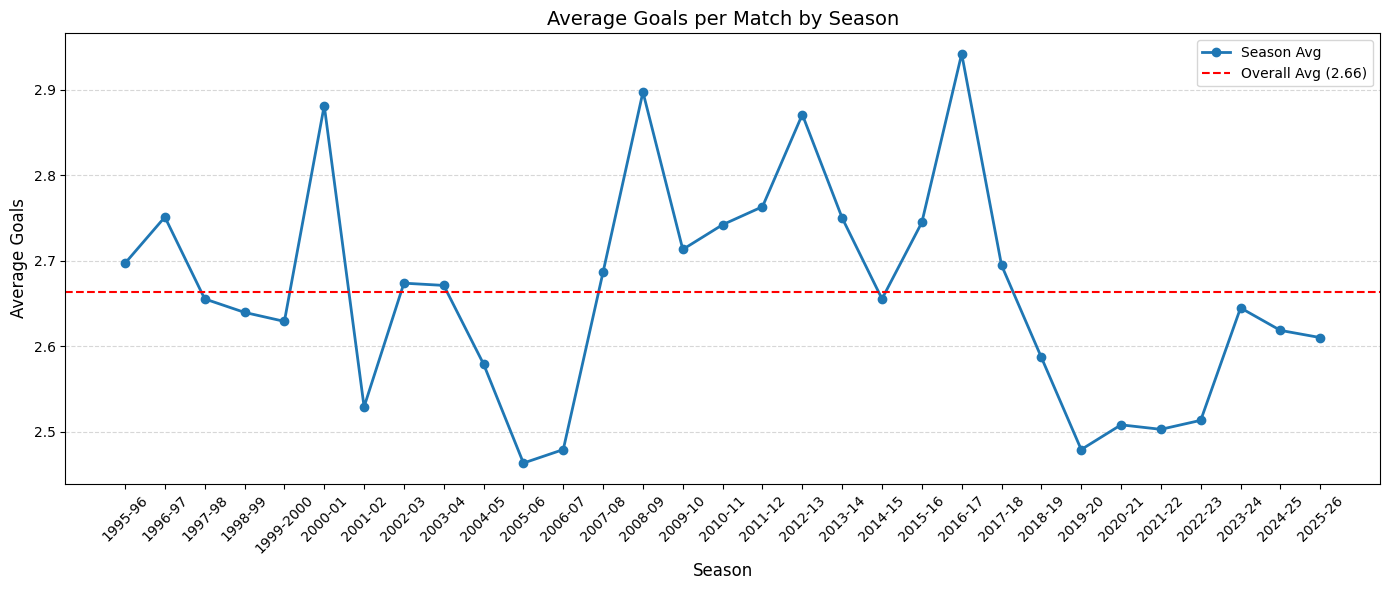

In [ ]:
season_goal_stats = df.groupby('Season')[['FTHG', 'FTAG']].mean()
season_goal_stats['TotalGoals'] = season_goal_stats['FTHG'] + season_goal_stats['FTAG']

mean_goals = season_goal_stats['TotalGoals'].mean()

plt.figure(figsize=(14,6))
plt.plot(
    season_goal_stats.index,
    season_goal_stats['TotalGoals'],
    marker='o',
    linewidth=2,
    label='Season Avg'
)

plt.axhline(
    mean_goals,
    color='red',
    linestyle='--',
    label=f'Overall Avg ({mean_goals:.2f})'
)

plt.title('Average Goals per Match by Season', fontsize=14)
plt.xlabel('Season', fontsize=12)
plt.ylabel('Average Goals', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

## Feature Engineering

We construct features based on recent team performance:

- Last 5 matches form (points, goal difference)
- Goals scored and conceded
- Venue-specific performance (home vs away)

We also create difference features between home and away teams to represent relative strength before each match.

These features are designed to capture team momentum and relative strength leading into each match.

### Time-Aware Feature Construction

All rolling features (e.g., last 5 matches form, goal difference, and venue-specific performance) are constructed using only past matches.

This is implemented using a shift operation before applying rolling calculations, ensuring that the current match is not included in its own feature values.

As a result, all features reflect information that would have been available prior to each match, preventing data leakage and ensuring realistic forecasting conditions.

In [ ]:
fe_df = df.copy()
fe_df = fe_df.sort_values(['Date']).reset_index(drop=True)

In [ ]:
fe_df['HomePoints'] = fe_df['FTR'].map({'H': 3, 'D': 1, 'A': 0})
fe_df['AwayPoints'] = fe_df['FTR'].map({'H': 0, 'D': 1, 'A': 3})

fe_df['HomeGoalsScored'] = fe_df['FTHG']
fe_df['HomeGoalsConceded'] = fe_df['FTAG']

fe_df['AwayGoalsScored'] = fe_df['FTAG']
fe_df['AwayGoalsConceded'] = fe_df['FTHG']

In [ ]:
home_rows = fe_df[['Season', 'Date', 'HomeTeam', 'AwayTeam',
                   'HomePoints', 'HomeGoalsScored', 'HomeGoalsConceded']].copy()

home_rows.columns = ['Season', 'Date', 'Team', 'Opponent',
                     'Points', 'GoalsScored', 'GoalsConceded']
home_rows['Venue'] = 'Home'

away_rows = fe_df[['Season', 'Date', 'AwayTeam', 'HomeTeam',
                   'AwayPoints', 'AwayGoalsScored', 'AwayGoalsConceded']].copy()

away_rows.columns = ['Season', 'Date', 'Team', 'Opponent',
                     'Points', 'GoalsScored', 'GoalsConceded']
away_rows['Venue'] = 'Away'

team_match_df = pd.concat([home_rows, away_rows], ignore_index=True)
team_match_df['GoalDiff'] = team_match_df['GoalsScored'] - team_match_df['GoalsConceded']
team_match_df = team_match_df.sort_values(['Team', 'Date']).reset_index(drop=True)

team_match_df.head()

,Season,Date,Team,Opponent,Points,GoalsScored,GoalsConceded,Venue,GoalDiff
0,1998-99,1998-08-29,Alaves,Betis,1,0,0,Home,0
1,1998-99,1998-09-13,Alaves,Oviedo,0,0,1,Away,-1
2,1998-99,1998-09-20,Alaves,Zaragoza,3,1,0,Home,1
3,1998-99,1998-09-27,Alaves,Tenerife,3,2,1,Away,1
4,1998-99,1998-10-04,Alaves,Santander,0,0,1,Home,-1


In [ ]:
team_match_df['Last5Points'] = (
    team_match_df.groupby('Team')['Points']
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).sum())
)

team_match_df['Last5GoalDiff'] = (
    team_match_df.groupby('Team')['GoalDiff']
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).sum())
)

team_match_df['Last5GoalsScored'] = (
    team_match_df.groupby('Team')['GoalsScored']
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).sum())
)

team_match_df['Last5GoalsConceded'] = (
    team_match_df.groupby('Team')['GoalsConceded']
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).sum())
)

In [ ]:
team_match_df['VenueLast5Points'] = (
    team_match_df.groupby(['Team', 'Venue'])['Points']
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).sum())
)

team_match_df['VenueLast5GoalDiff'] = (
    team_match_df.groupby(['Team', 'Venue'])['GoalDiff']
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).sum())
)

team_match_df['VenueLast5GoalsScored'] = (
    team_match_df.groupby(['Team', 'Venue'])['GoalsScored']
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).sum())
)

team_match_df['VenueLast5GoalsConceded'] = (
    team_match_df.groupby(['Team', 'Venue'])['GoalsConceded']
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).sum())
)

In [ ]:
home_features = team_match_df[team_match_df['Venue'] == 'Home'].copy()
home_features = home_features.rename(columns={
    'Team': 'HomeTeam',
    'Opponent': 'AwayTeam',
    'Last5Points': 'Home_Last5Points',
    'Last5GoalDiff': 'Home_Last5GoalDiff',
    'Last5GoalsScored': 'Home_Last5GoalsScored',
    'Last5GoalsConceded': 'Home_Last5GoalsConceded',
    'VenueLast5Points': 'Home_VenueLast5Points',
    'VenueLast5GoalDiff': 'Home_VenueLast5GoalDiff',
    'VenueLast5GoalsScored': 'Home_VenueLast5GoalsScored',
    'VenueLast5GoalsConceded': 'Home_VenueLast5GoalsConceded'
})

away_features = team_match_df[team_match_df['Venue'] == 'Away'].copy()
away_features = away_features.rename(columns={
    'Team': 'AwayTeam',
    'Opponent': 'HomeTeam',
    'Last5Points': 'Away_Last5Points',
    'Last5GoalDiff': 'Away_Last5GoalDiff',
    'Last5GoalsScored': 'Away_Last5GoalsScored',
    'Last5GoalsConceded': 'Away_Last5GoalsConceded',
    'VenueLast5Points': 'Away_VenueLast5Points',
    'VenueLast5GoalDiff': 'Away_VenueLast5GoalDiff',
    'VenueLast5GoalsScored': 'Away_VenueLast5GoalsScored',
    'VenueLast5GoalsConceded': 'Away_VenueLast5GoalsConceded'
})

model_df = df.merge(
    home_features[['Date', 'HomeTeam', 'AwayTeam',
                   'Home_Last5Points', 'Home_Last5GoalDiff',
                   'Home_Last5GoalsScored', 'Home_Last5GoalsConceded',
                   'Home_VenueLast5Points', 'Home_VenueLast5GoalDiff',
                   'Home_VenueLast5GoalsScored', 'Home_VenueLast5GoalsConceded']],
    on=['Date', 'HomeTeam', 'AwayTeam'],
    how='left'
)

model_df = model_df.merge(
    away_features[['Date', 'HomeTeam', 'AwayTeam',
                   'Away_Last5Points', 'Away_Last5GoalDiff',
                   'Away_Last5GoalsScored', 'Away_Last5GoalsConceded',
                   'Away_VenueLast5Points', 'Away_VenueLast5GoalDiff',
                   'Away_VenueLast5GoalsScored', 'Away_VenueLast5GoalsConceded']],
    on=['Date', 'HomeTeam', 'AwayTeam'],
    how='left'
)

model_df.head()

,Season,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,FTR_Label,TotalGoals,Home_Last5Points,Home_Last5GoalDiff,Home_Last5GoalsScored,Home_Last5GoalsConceded,Home_VenueLast5Points,Home_VenueLast5GoalDiff,Home_VenueLast5GoalsScored,Home_VenueLast5GoalsConceded,Away_Last5Points,Away_Last5GoalDiff,Away_Last5GoalsScored,Away_Last5GoalsConceded,Away_VenueLast5Points,Away_VenueLast5GoalDiff,Away_VenueLast5GoalsScored,Away_VenueLast5GoalsConceded
0,1995-96,1995-09-02,La Coruna,Valencia,3,0,H,2.0,0.0,H,Home Win,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1995-96,1995-09-02,Sp Gijon,Albacete,3,0,H,3.0,0.0,H,Home Win,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1995-96,1995-09-03,Ath Bilbao,Santander,4,0,H,2.0,0.0,H,Home Win,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1995-96,1995-09-03,Ath Madrid,Sociedad,4,1,H,1.0,1.0,D,Home Win,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1995-96,1995-09-03,Celta,Compostela,0,1,A,0.0,0.0,D,Away Win,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
model_df['FormDiff'] = model_df['Home_Last5Points'] - model_df['Away_Last5Points']
model_df['GoalDiffFormDiff'] = model_df['Home_Last5GoalDiff'] - model_df['Away_Last5GoalDiff']
model_df['GoalsScoredFormDiff'] = model_df['Home_Last5GoalsScored'] - model_df['Away_Last5GoalsScored']
model_df['GoalsConcededFormDiff'] = model_df['Home_Last5GoalsConceded'] - model_df['Away_Last5GoalsConceded']

model_df['VenueFormDiff'] = model_df['Home_VenueLast5Points'] - model_df['Away_VenueLast5Points']
model_df['VenueGoalDiffFormDiff'] = model_df['Home_VenueLast5GoalDiff'] - model_df['Away_VenueLast5GoalDiff']
model_df['VenueGoalsScoredDiff'] = model_df['Home_VenueLast5GoalsScored'] - model_df['Away_VenueLast5GoalsScored']
model_df['VenueGoalsConcededDiff'] = model_df['Home_VenueLast5GoalsConceded'] - model_df['Away_VenueLast5GoalsConceded']

These features represent pre-match information only, ensuring that the model reflects realistic forecasting conditions and avoids data leakage.

## Model Building

The goal is to predict match outcomes (home win, draw, away win) using pre-match features.

We train two models:
- Logistic Regression (baseline)
- Random Forest (nonlinear model)

Data is split chronologically by season to simulate real-world forecasting, where future matches are predicted using only past information.

- Training: before 2022–23  
- Testing: 2022–23 through 2024–25

In [ ]:
model_df = model_df.dropna().reset_index(drop=True)
model_df['FTR_encoded'] = model_df['FTR'].map({'H': 0, 'D': 1, 'A': 2})

features = [
    'FormDiff',
    'GoalDiffFormDiff',
    'GoalsScoredFormDiff',
    'GoalsConcededFormDiff',
    'VenueFormDiff',
    'VenueGoalDiffFormDiff',
    'VenueGoalsScoredDiff',
    'VenueGoalsConcededDiff'
]

train_df = model_df[model_df['Season'] < '2022-23']
test_df = model_df[(model_df['Season'] >= '2022-23') & (model_df['Season'] < '2025-26')]

X_train = train_df[features]
y_train = train_df['FTR_encoded']

X_test = test_df[features]
y_test = test_df['FTR_encoded']

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (10349, 8)
Test shape: (1140, 8)


Early matches with insufficient prior history were removed after feature construction so that all model inputs reflect pre-match information consistently.

In [ ]:
baseline_acc = y_test.value_counts(normalize=True).max()
print("Baseline accuracy (majority class):", round(baseline_acc, 4))

Baseline accuracy (majority class): 0.4544


In [ ]:
log_reg_model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=2000, class_weight='balanced'))
])

log_reg_model.fit(X_train, y_train)
y_pred_log = log_reg_model.predict(X_test)

print("Logistic Regression Accuracy:", round(accuracy_score(y_test, y_pred_log), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_log, zero_division=0))

Logistic Regression Accuracy: 0.4746

Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.57      0.58       518
           1       0.27      0.13      0.17       293
           2       0.41      0.64      0.50       329

    accuracy                           0.47      1140
   macro avg       0.43      0.44      0.42      1140
weighted avg       0.46      0.47      0.45      1140



Logistic Regression is used as a baseline model. Random Forest is then used as a more flexible nonlinear model for comparison.

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", round(accuracy_score(y_test, y_pred_rf), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, zero_division=0))

Random Forest Accuracy: 0.4482

Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.55      0.56       518
           1       0.27      0.27      0.27       293
           2       0.42      0.45      0.43       329

    accuracy                           0.45      1140
   macro avg       0.42      0.42      0.42      1140
weighted avg       0.45      0.45      0.45      1140



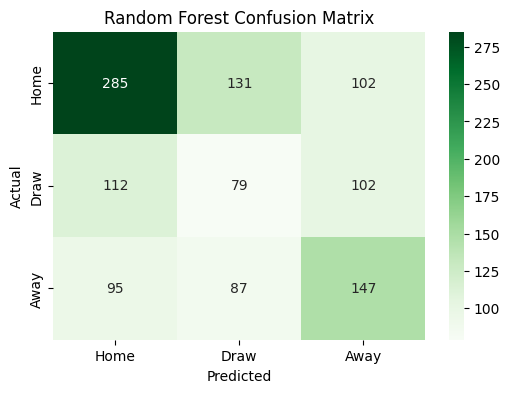

In [ ]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm_rf, annot=True, fmt='d', cmap='Greens',
    xticklabels=['Home', 'Draw', 'Away'],
    yticklabels=['Home', 'Draw', 'Away']
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Confusion Matrix')
plt.show()

In [ ]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=features
).sort_values(ascending=False)

print(feature_importance)

VenueGoalDiffFormDiff     0.137930
GoalDiffFormDiff          0.136363
GoalsScoredFormDiff       0.127470
FormDiff                  0.123701
VenueFormDiff             0.123637
VenueGoalsScoredDiff      0.122341
VenueGoalsConcededDiff    0.115590
GoalsConcededFormDiff     0.112968
dtype: float64


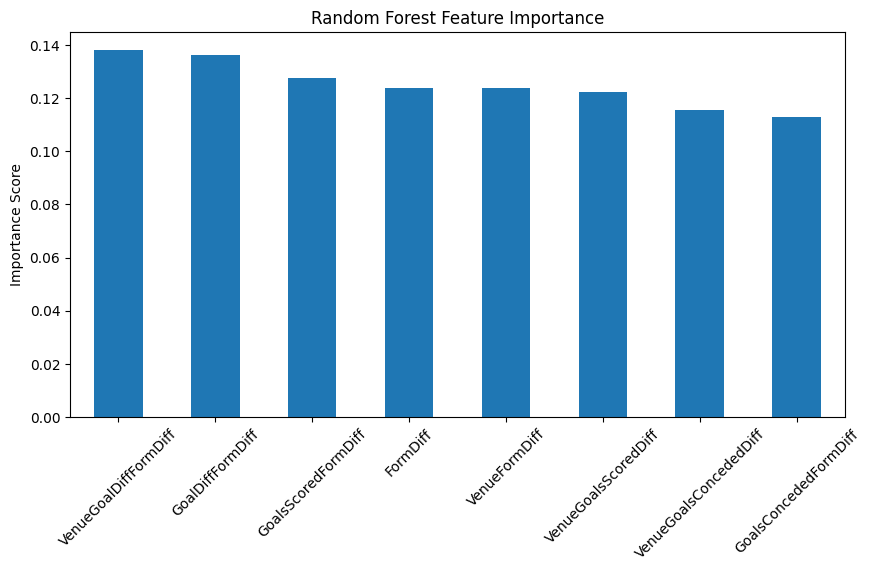

In [ ]:
plt.figure(figsize=(10,5))
feature_importance.plot(kind='bar')
plt.title('Random Forest Feature Importance')
plt.ylabel('Importance Score')
plt.xticks(rotation=45)
plt.show()

In [ ]:
print("Baseline Accuracy:", round(baseline_acc, 4))
print("Logistic Regression Accuracy:", round(accuracy_score(y_test, y_pred_log), 4))
print("Random Forest Accuracy:", round(accuracy_score(y_test, y_pred_rf), 4))

Baseline Accuracy: 0.4544
Logistic Regression Accuracy: 0.4746
Random Forest Accuracy: 0.4482


The Logistic Regression model performs slightly above the majority-class baseline, indicating moderate predictive power from recent-form and venue-based features.

The Random Forest model provides a useful nonlinear comparison, though in this run it performs slightly below the Logistic Regression baseline in overall accuracy.

Feature importance shows that recent goal-related metrics and venue-specific performance are among the strongest predictors of match outcomes.

In [ ]:
from sklearn.metrics import log_loss

rf_probs = rf_model.predict_proba(X_test)
rf_logloss = log_loss(y_test, rf_probs)

print("Random Forest Log Loss:", round(rf_logloss, 4))

Random Forest Log Loss: 1.0543


In [ ]:
baseline_probs = y_train.value_counts(normalize=True).sort_index()
baseline_pred_probs = np.tile(baseline_probs.values, (len(y_test), 1))

baseline_logloss = log_loss(y_test, baseline_pred_probs)

print("Baseline Log Loss:", round(baseline_logloss, 4))

Baseline Log Loss: 1.0673


The Random Forest model achieves a slightly lower log loss than the baseline, indicating that its predicted probabilities are better calibrated and more informative than naive historical frequency estimates.

### Probability Evaluation

To evaluate the quality of predicted probabilities, we use log loss, which measures how well predicted probabilities align with actual outcomes.

We compare the model against a simple baseline that uses historical outcome frequencies (home win, draw, away win).

This ensures that the model provides meaningful probabilistic improvements beyond naive assumptions.

In this case, the Random Forest model achieves a slightly lower log loss than the baseline, indicating improved probability quality.

## Season Simulation

Instead of predicting a single deterministic outcome for each match, we use predicted probabilities to simulate match results.

Each match outcome is sampled from the model’s predicted probability distribution. This produces one possible realization of a league season under uncertainty.

In [ ]:
season_to_predict = '2024-25'
single_season_df = test_df[test_df['Season'] == season_to_predict].copy()

print("Number of matches in selected season:", single_season_df.shape[0])

Number of matches in selected season: 380


In [ ]:
season_probs = rf_model.predict_proba(single_season_df[features])

pred_classes = [np.random.choice([0, 1, 2], p=p) for p in season_probs]

result_map_rev = {0: 'H', 1: 'D', 2: 'A'}
pred_results = pd.Series(pred_classes).map(result_map_rev)

single_season_df = single_season_df.copy()
single_season_df['PredictedResult'] = pred_results.values

single_season_df[['HomeTeam', 'AwayTeam', 'PredictedResult']].head()

,HomeTeam,AwayTeam,PredictedResult
11109,Ath Bilbao,Getafe,D
11110,Betis,Girona,D
11111,Celta,Alaves,H
11112,Las Palmas,Sevilla,D
11113,Osasuna,Leganes,H


In [ ]:
single_season_df['PredHomePoints'] = single_season_df['PredictedResult'].map({'H': 3, 'D': 1, 'A': 0})
single_season_df['PredAwayPoints'] = single_season_df['PredictedResult'].map({'H': 0, 'D': 1, 'A': 3})

The following table shows one simulated league season based on probability-sampled match outcomes.

In [ ]:
home_table = single_season_df.groupby('HomeTeam').agg(
    HomePlayed=('HomeTeam', 'count'),
    HomePoints=('PredHomePoints', 'sum'),
    HomeGoalsFor=('FTHG', 'sum'),
    HomeGoalsAgainst=('FTAG', 'sum')
).reset_index().rename(columns={'HomeTeam': 'Team'})

away_table = single_season_df.groupby('AwayTeam').agg(
    AwayPlayed=('AwayTeam', 'count'),
    AwayPoints=('PredAwayPoints', 'sum'),
    AwayGoalsFor=('FTAG', 'sum'),
    AwayGoalsAgainst=('FTHG', 'sum')
).reset_index().rename(columns={'AwayTeam': 'Team'})

league_table = pd.merge(home_table, away_table, on='Team', how='outer').fillna(0)

league_table['Played'] = league_table['HomePlayed'] + league_table['AwayPlayed']
league_table['Points'] = league_table['HomePoints'] + league_table['AwayPoints']
league_table['GoalsFor'] = league_table['HomeGoalsFor'] + league_table['AwayGoalsFor']
league_table['GoalsAgainst'] = league_table['HomeGoalsAgainst'] + league_table['AwayGoalsAgainst']
league_table['GoalDifference'] = league_table['GoalsFor'] - league_table['GoalsAgainst']

league_table = league_table[['Team', 'Played', 'Points', 'GoalsFor', 'GoalsAgainst', 'GoalDifference']]

league_table = league_table.sort_values(
    by=['Points', 'GoalDifference', 'GoalsFor'],
    ascending=False
).reset_index(drop=True)

league_table.index = league_table.index + 1
league_table.index.name = 'Rank'

league_table

,Team,Played,Points,GoalsFor,GoalsAgainst,GoalDifference
Rank,,,,,,
1,Real Madrid,38,71,78,38,40
2,Barcelona,38,70,102,39,63
3,Girona,38,66,44,60,-16
4,Celta,38,60,59,57,2
5,Espanol,38,56,40,51,-11
6,Sociedad,38,56,35,46,-11
7,Betis,38,55,57,50,7
8,Ath Madrid,38,52,68,30,38
9,Villarreal,38,52,71,51,20


Points are based on simulated match outcomes, while goals for and against are retained from the observed season for simplicity and to preserve realistic goal distributions.

In [ ]:
print("Predicted league winner:", league_table.iloc[0]['Team'])

Predicted league winner: Real Madrid


## Monte Carlo Simulation

We simulate the 2024–25 La Liga season using the set of matches for that season.

Match outcomes are generated by sampling from predicted probabilities produced by the Random Forest model trained on historical data using time-aware features.

A total of 200 simulations are performed, where each simulation produces a full league table.

These simulations are used to estimate season-level outcomes such as:
- Title-winning probabilities
- Top 4 probabilities
- Expected points per team

Results are aggregated across simulations to capture uncertainty in match outcomes.

Due to the relatively small number of simulations (200), estimated probabilities may exhibit some variability and should be interpreted as approximate.

In [ ]:
n_simulations = 200

winners = []
top4_counts = {}
points_tracker = {}

for i in range(n_simulations):
    season_probs = rf_model.predict_proba(single_season_df[features])
    pred_classes = [np.random.choice([0, 1, 2], p=p) for p in season_probs]
    pred_results = pd.Series(pred_classes).map({0: 'H', 1: 'D', 2: 'A'})

    sim_season = single_season_df.copy()
    sim_season['PredictedResult'] = pred_results.values

    sim_season['HomePoints'] = sim_season['PredictedResult'].map({'H': 3, 'D': 1, 'A': 0})
    sim_season['AwayPoints'] = sim_season['PredictedResult'].map({'H': 0, 'D': 1, 'A': 3})

    home_points = sim_season.groupby('HomeTeam')['HomePoints'].sum()
    away_points = sim_season.groupby('AwayTeam')['AwayPoints'].sum()

    table = (home_points + away_points).reset_index()
    table.columns = ['Team', 'Points']
    table = table.sort_values(by='Points', ascending=False).reset_index(drop=True)

    winners.append(table.iloc[0]['Team'])

    top4 = table.head(4)['Team']
    for team in top4:
        top4_counts[team] = top4_counts.get(team, 0) + 1

    for team, pts in table.set_index('Team')['Points'].items():
        points_tracker.setdefault(team, []).append(pts)

In [ ]:
winner_counts = pd.Series(winners).value_counts()
winner_probs = (winner_counts / n_simulations * 100).round(2)

print("Winning probabilities (%):")
print(winner_probs)

Winning probabilities (%):
Barcelona      60.5
Real Madrid    17.0
Ath Madrid      7.5
Villarreal      5.5
Ath Bilbao      3.0
Celta           2.0
Betis           1.0
Mallorca        1.0
Osasuna         1.0
Sevilla         0.5
Valencia        0.5
Sociedad        0.5
Name: count, dtype: float64


In [ ]:
top4_probs = pd.Series(
    {team: (count / n_simulations) * 100 for team, count in top4_counts.items()}
).sort_values(ascending=False).round(2)

print("Top 4 probabilities (%):")
print(top4_probs)

Top 4 probabilities (%):
Barcelona      92.0
Real Madrid    64.0
Ath Madrid     51.5
Villarreal     38.5
Ath Bilbao     31.0
Betis          21.5
Celta          20.0
Girona         14.5
Mallorca        9.0
Sevilla         8.0
Valencia        8.0
Sociedad        7.0
Vallecano       6.5
Alaves          6.5
Getafe          6.0
Osasuna         5.5
Espanol         3.5
Las Palmas      3.5
Leganes         3.0
Valladolid      0.5
dtype: float64


In [ ]:
avg_points = pd.Series(
    {team: np.mean(pts) for team, pts in points_tracker.items()}
).sort_values(ascending=False).round(2)

print("Average points per team:")
print(avg_points)

Average points per team:
Barcelona      70.95
Real Madrid    63.36
Ath Madrid     60.16
Villarreal     56.68
Ath Bilbao     55.78
Celta          53.53
Betis          53.26
Girona         50.38
Valencia       49.40
Mallorca       48.94
Alaves         48.72
Sociedad       48.22
Vallecano      48.16
Osasuna        47.68
Espanol        46.76
Sevilla        46.62
Getafe         46.36
Leganes        44.74
Las Palmas     44.66
Valladolid     38.17
dtype: float64


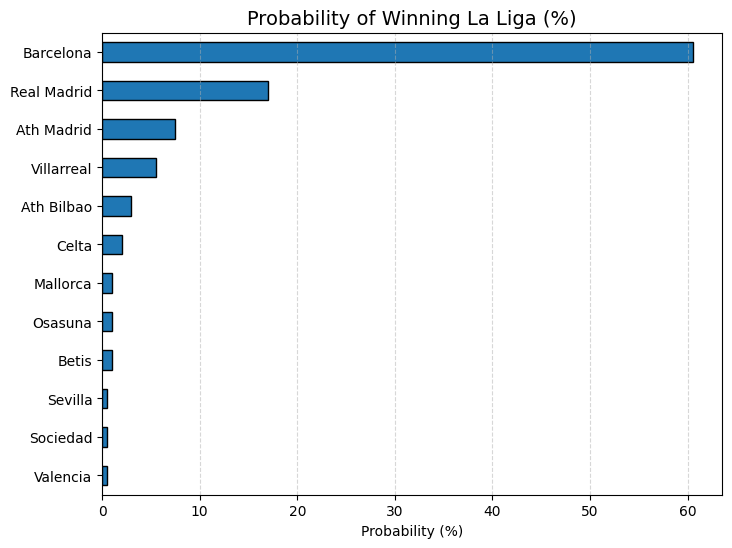

In [ ]:
winner_probs.sort_values().plot(kind='barh', figsize=(8,6), edgecolor='black')
plt.title('Probability of Winning La Liga (%)', fontsize=14)
plt.xlabel('Probability (%)')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

## Simulation Results Interpretation

Barcelona emerges as the most likely champion, winning approximately 60% of simulations, indicating a clear advantage over other teams.

Real Madrid is the second strongest contender, while teams such as Atletico Madrid and Villarreal appear as competitive but less dominant challengers.

Top 4 probabilities highlight teams that consistently perform well across simulations, while mid-table teams show higher variability.

Average points reinforce these findings, providing an estimate of expected team performance over a simulated season.

## Conclusion

This project demonstrates that match-level features such as recent form, goal differences, and venue-specific performance can be used to build predictive models for football match outcomes.

The model shows moderate predictive performance, but more importantly provides meaningful probability estimates that can be used for simulation.

By incorporating probabilistic predictions into Monte Carlo simulations, we move beyond single-outcome forecasting and instead estimate full-season uncertainty, including title probabilities and expected performance.

The results highlight how probabilistic modeling provides deeper insight into competitive balance and variability in sports outcomes.

## Limitations

This model does not account for player-level information such as injuries, transfers, or tactical changes.

Additionally, simulated league tables use predicted match results for points while retaining observed goal statistics.

Future work could incorporate richer datasets and more detailed match simulations.